# Imports #

In [258]:
import numpy as np 
import matplotlib.pyplot as plt
import math 

# Rational Bezier Function #

In [259]:
def b_polynomial(t,P):
    n = len(P)-1
    num_x = np.zeros([n+1,len(t)])
    num_y = np.zeros([n+1,len(t)])
    denom = np.zeros([n+1, len(t)])

    for i in range(n+1):
        w = P[i][0]
        x = P[i][1]
        y = P[i][2]
        comb = math.comb(n,i)
        B_i = comb*(t**i)*(1-t)**(n-i)
        num_x[i,:]= B_i*w*x
        num_y[i,:]=B_i*w*y
        denom[i,:]=B_i*w
    B_x = np.sum(num_x,axis=0)
    B_y = np.sum(num_y,axis=0)
    B_denom = np.sum(denom, axis=0)
    return B_x/B_denom, B_y/B_denom 

# Function to create ECG signal #

In [ ]:
def ECG_wave(signal_type):
    t = np.linspace(0,1,101)
    #Checking signal type 
    if signal_type == 'Normal':
       #points_preP = [[1,0,0],[1,0.5,0],[1,1,0],[1,1.5,0],[1,2,0],[1,2.5,0],[1,3,0]]
       points_P = [[1,0,0],[1.5,0.2,0.03],[1,0.4,0.12],[1,0.6,0.3],[1.5,1.6,0.9],[3,2.6,1.3],[1,3.6,0.8],[1,3.9,0.5],[1,4.2,0.16],[1.5,4.4,0.04],[1,4.6,0]]
       #points_P = [[5,3.5,0],[1,4,0.3],[2,5,0.9],[10,6,1.3],[2,7,0.8],[1.5,7.3,0.5],[5,8,0]]
       points_preQRS = [[1,4.85,0],[1,5.1,0],[1,5.35,0],[1,5.6,0],[1,5.85,0],[1,6.1,0],[1,6.6,0]]
       points_QRS = [[10,6.6,0],[10,6.8,0],[100,6.9,-0.05],[1,6.98,-0.2],[1,7.2,-0.65],[700,7.7,-1.5],[10,7.85,0],[1,8,2.5],[10,8.2,5.5],[1000,8.6,11],[10,8.95,5.5],[1,9.1,2.5],[1,9.25,0],[700,9.45,-3.3],[1,9.95,-1.5],[10,10.3,-0.1],[100,10.4,-0.03],[10,10.5,0]]
       #points_QRS = [[10,10.3,0],[500,11.1,-1.5],[10,11.25,0],[1000,12,11],[10,12.65,0],[500,12.85,-3.3],[10,13.7,0]]
       points_preT = [[1,10.6,0],[1,11.1,0],[1,11.35,0],[1,11.6,0],[1,12.1,0],[1,12.6,0],[1,13.1,0]]
       #points_T = [[5,17,0],[1,18,1],[2,19,1.9],[10,19.6,2.1],[2,21,0.55],[5,21.4,0]]
       points_T = [[1,13.5,0],[5,13.6,0],[2,13.65,0.04],[1,13.8,0.1],[1,14.6,1],[2,15.6,1.9],[10,16.2,2.1],[2,17.6,0.55],[1,17.8,0.15],[5,17.9,0.05],[1,18.02,0]]
       #points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]
       
       #prePx,prePy = b_polynomial(t,points_preP)
       Px,Py = b_polynomial(t,points_P)
       preQRSx,preQRSy = b_polynomial(t,points_preQRS)
       QRSx,QRSy = b_polynomial(t, points_QRS)
       preTx, preTy = b_polynomial(t, points_preT)
       Tx,Ty = b_polynomial(t, points_T)
       #postTx, postTy = b_polynomial(t, points_postT)
       
       x = np.concatenate((Px, preQRSx,QRSx, preTx, Tx),axis=0)
       y = np.concatenate((Py,preQRSy, QRSy, preTy, Ty),axis=0)
 
    elif signal_type == "Ventricular pacing":
        #points_preP = [[1,0,0],[1,1,0],[1,2,0],[1,2.5,0]]
        points_P = [[10,0,0],[5,0.7,0.7],[15,1.25,0.9],[15,1.35,0.9],[5,1.8,0.7],[10,2.5,0]]
        points_prePacemaker = [[1,2.6,0],[1,3.1,0],[1,4.1,0],[1,5.1,0]]
        points_Pacemaker = [[1,5.4,0],[10,5.5,14],[1,5.6,0]]
        points_QRS = [[2,6.1,-0.8],[1,6.6,-3.1],[5,7,-7.1],[5,7.3,-7.6],[1,7.6,-11.5],[10,8.15,-16.8],[1,8.6,-14.6],[1,9.1,-10.5],[1,9.6,-6.4],[1,10.1,-3],[10,10.7,0]]
        points_T = [[10,10.71,0],[1,10.9,0.4],[1,11.1,0.75],[1,11.6,1.8],[1,12.1,2.75],[1,12.6,3.6],[1,13.1,4.15],[5,13.6,4.75],[5,14.1,5.4],[15,14.55,5.7],[5,15.1,5.3],[5,15.6,4.4],[1,16.1,3],[1,16.6,1.6],[1,17.1,0.5],[1,17.5,0]]
        #points_postT = [[1,21,0],[1,22,0],[1,23,0],[1,24,0],[1,25,0]]

        #prePx,prePy = b_polynomial(t,points_preP)
        Px,Py = b_polynomial(t,points_P)
        prePacemakerx, prePacemakery = b_polynomial(t,points_prePacemaker)
        Pacemakerx, Pacemakery = b_polynomial(t,points_Pacemaker)
        QRSx,QRSy = b_polynomial(t, points_QRS)
        Tx,Ty = b_polynomial(t, points_T)
        #postTx, postTy = b_polynomial(t, points_postT)

        x = np.concatenate((Px, prePacemakerx, Pacemakerx, QRSx, Tx),axis=0)
        y = np.concatenate((Py,prePacemakery, Pacemakery, QRSy, Ty),axis=0)

    elif signal_type == "Mobitz type II - no conduction":
        #points_preP = [[1,0,0],[1,0.5,0],[1,1,0],[1,1.5,0],[1,2,0],[1,2.5,0],[1,3,0]]
        #points_preP = [[1, 0.0, 0], [1, 0.125, 0], [1, 0.25, 0], [1, 0.375, 0], [1, 0.5, 0], [1, 0.625, 0], [1, 0.75, 0]]
        #points_P = [[1,3.4,0],[1.5,3.6,0.03],[1,3.8,0.12],[1,4,0.3],[1.5,5,0.9],[3,6,1.3],[1,7,0.8],[1,7.3,0.5],[1,7.6,0.16],[1.5,7.8,0.04],[1,8,0]]
        points_P = [[1,0,0],[1.5,0.2,0.03],[1,0.4,0.12],[1,0.6,0.3],[1.5,1.6,0.9],[3,2.6,1.3],[1,3.6,0.8],[1,3.9,0.5],[1,4.2,0.16],[1.5,4.4,0.04],[1,4.6,0]]
        #points_P = [[1, 0.85, 0], [1.5, 0.9, 0.03], [1, 0.95, 0.12], [1, 1.0, 0.3], [1.5, 1.25, 0.9], [3, 1.5, 1.3], [1, 1.75, 0.8], [1, 1.825, 0.5], [1, 1.9, 0.16], [1.5, 1.95, 0.04], [1, 2.0, 0]]
        #points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]
        #points_postT = [[1, 5.375, 0], [1, 5.5, 0], [1, 5.625, 0], [1, 5.75, 0], [1, 5.875, 0], [1, 6.0, 0]]

       
        #prePx,prePy = b_polynomial(t,points_preP)
        Px,Py = b_polynomial(t,points_P)
        # preQRSx,preQRSy = b_polynomial(t,points_preQRS)
        # QRSx,QRSy = b_polynomial(t, points_QRS)
        # preTx, preTy = b_polynomial(t, points_preT)
        # Tx,Ty = b_polynomial(t, points_T)
        #postTx, postTy = b_polynomial(t, points_postT)
       
        # x = np.concatenate((Px, postTx),axis=0)
        # y = np.concatenate((Py,postTy),axis=0)
        x = Px
        y = Py

    elif signal_type == 'Slow conduction':
        points_P = [[1,0,0],[1.5,0.2,0.03],[1,0.4,0.12],[1,0.6,0.3],[1.5,1.6,0.9],[3,2.6,1.3],[1,3.6,0.8],[1,3.9,0.5],[1,4.2,0.16],[1.5,4.4,0.04],[1,4.6,0]]
        #points_P = [[5,3.5,0],[1,4,0.3],[2,5,0.9],[10,6,1.3],[2,7,0.8],[1.5,7.3,0.5],[5,8,0]]
        points_preQRS = [[1,4.85,0],[1,5.1,0],[1,5.35,0],[1,5.6,0],[1,5.85,0],[1,6.1,0],[1,6.6,0]]
        points_QRS = [[10,6.6,0],[10,6.8,0],[100,6.9,-0.05],[1,6.98,-0.2],[1,7.2,-0.65],[700,7.7,-1.5],[10,7.85,0],[1,8,2.5],[10,8.2,5.5],[1000,8.6,11],[10,8.95,5.5],[1,9.1,2.5],[1,9.25,0],[700,9.45,-3.3],[1,9.95,-1.5],[10,10.3,-0.1],[100,10.4,-0.03],[10,10.5,0]]
        #points_preT = [[1,14,0],[1,14.5,0],[1,14.75,0],[1,15,0],[1,15.5,0],[1,16,0],[1,16.5,0]]
        points_preT = [[1,17.6,0],[1,18.1,0],[1,18.35,0],[1,18.6,0],[1,19.1,0],[1,19.6,0],[1,20.1,0]]
        #points_T = [[1,16.9,0],[2,17.05,0.04],[1,17.2,0.1],[5,17,0],[1,18,1],[2,19,1.9],[10,19.6,2.1],[2,21,0.55],[1,21.2,0.15],[5,21.3,0.05],[1,21.42,0]]
        points_T = [[1,20.5,0],[5,20.6,0],[2,20.65,0.04],[1,20.8,0.1],[1,21.6,1],[2,22.6,1.9],[10,23.2,2.1],[2,24.6,0.55],[1,24.8,0.15],[5,24.9,0.05],[1,25.02,0]]
        #points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]
        #points_postT = [[1,28.5,0],[1,29,0],[1,29.5,0],[1,30,0],[1,30.5,0],[1,31,0]]

       
        #prePx,prePy = b_polynomial(t,points_preP)
        Px,Py = b_polynomial(t,points_P)
        preQRSx,preQRSy = b_polynomial(t,points_preQRS)
        QRSx,QRSy = b_polynomial(t, points_QRS)
        preTx, preTy = b_polynomial(t, points_preT)
        Tx,Ty = b_polynomial(t, points_T)
        #postTx, postTy = b_polynomial(t, points_postT)
       
        x = np.concatenate((Px, preQRSx,QRSx, preTx, Tx),axis=0)
        y = np.concatenate((Py,preQRSy, QRSy, preTy, Ty),axis=0)

    elif signal_type == '3rd degree heart block P wave':
        points_P = [[1,0,0],[2,0.07,0.02],[1,0.15,0.12],[1,0.25,0.44],[2,0.35,0.65],[3,0.465,0.74],[2,0.6,0.63],[1,0.65,0.52],[1,0.75,0.16],[1,0.8,0.05],[2,0.85,0.01],[1,0.9,0]]
        x, y = b_polynomial(t, points_P)

    elif signal_type == "3rd degree heart block R wave":
        points_R_first = [[1,0,0],[2,0.05,0.05],[1,0.1,0.15],[1,0.15,0.8],[5,0.225,1.2],[1,0.28,0.8],[1,0.3,0.4],[2,0.32,0]]
        points_R_second = [[2,0.32,0],[1,0.35,-1.2],[1,0.4,-2.6],[1,0.45,-3.6],[5,0.55,-4.4],[2,0.65,-4],[1,0.7,-3.8],[1,0.75,-3.6],[1,0.8,-3.2],[1,0.9,-3],[2,1,-2.6],[1,1.05,-2.2],[1,1.1,-1.2],[1,1.15,-0.6],[1,1.2,-0.2],[1,1.25,-0.1],[2,1.27,-0.05],[1,1.3,0]]
        points_R_third = [[1,1.3,0],[1,1.35,0.15],[1,1.4,0.25],[1,1.45,0.35],[1,1.5,0.44],[1,1.6,0.58],[1,1.7,0.77],[1,1.8,0.95],[1,1.9,1.15],[1,2,1.34],[2,2.1,1.58],[3,2.23,1.8],[2,2.3,1.75],[1,2.4,1.6],[1,2.5,1.3],[1,2.6,1],[1,2.7,0.6],[1,1.8,0.36],[1,2.9,0.15],[1,2.95,0.1],[2,3,0.03],[1,3.05,0]]

        R_firstx, R_firsty = b_polynomial(t, points_R_first)
        R_secondx, R_secondy = b_polynomial(t, points_R_second)
        R_thirdx, R_thirdy = b_polynomial(t, points_R_third)

        x = np.concatenate((R_firstx,R_secondx,R_thirdx),axis=0)
        y = np.concatenate((R_firsty,R_secondy,R_thirdy),axis=0)

    elif signal_type == "3rd degree heart block ventricular pacing":
        points_Pacemaker = [[1,0,0],[10,0.032,14],[1,0.064,0]]
        points_QRS = [[2,0.224,-0.8],[1,0.384,-3.1],[5,0.512,-7.1],[5,0.608,-7.6],[1,0.704,-11.5],[10,0.88,-16.8],[1,1.024,-14.6],[1,1.184,-10.5],[1,1.344,-6.4],[1,1.504,-3],[10,1.696,0]]
        points_T = [[10,1.6992,0],[1,1.76,0.4],[1,1.824,0.75],[1,1.984,1.8],[1,2.144,2.75],[1,2.304,3.6],[1,2.464,4.15],[5,2.624,4.75],[5,2.784,5.4],[15,2.928,5.7],[5,3.104,5.3],[5,3.264,4.4],[1,3.424,3],[1,3.584,1.6],[1,3.744,0.5],[1,3.872,0]]

        pacemaker_x, pacemaker_y = b_polynomial(t,points_Pacemaker)
        pacedQRS_x,pacedQRS_y = b_polynomial(t,points_QRS)
        T_x,T_y = b_polynomial(t,points_T)

        x = np.concatenate((pacemaker_x,pacedQRS_x,T_x),axis=0)
        y = np.concatenate((pacemaker_y,pacedQRS_y,T_y),axis=0)
    
        
    

    return x,y


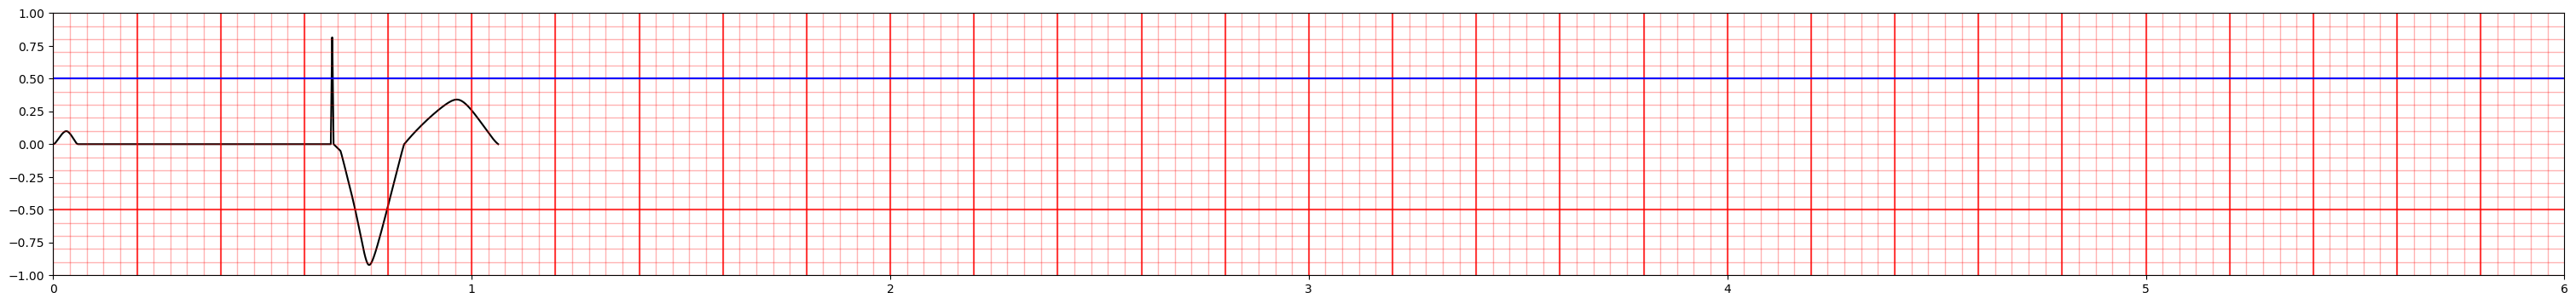

In [385]:
t = np.linspace(0,1,101)
patient_HR = 90
sensitivity = 0.5
max_time_since_sensed = 60/90

scaling_factor_x_R = 0.28/3.05 #Length of signal is 3.05, but actual length should be 0.28s
scaling_factor_x_P = 0.06/0.9 #Length of signal is 0.9, but actual length should be 0.06s
scaling_factor_y_R = 0.295 + 0.06*np.random.random()-0.03
scaling_factor_y_P = 0.1477 + 0.06*np.random.random()-0.03
scaling_factor_x_paced = 0.4/3.872 #Length of signal is 3.872, but actual length should be 0.4s   
scaling_factor_y_paced = 1.333*(0.05 + 0.006*np.random.random()-0.003)



Px,Py = ECG_wave("3rd degree heart block P wave")
Rx,Ry = ECG_wave("3rd degree heart block R wave")
paced_x, paced_y = ECG_wave("3rd degree heart block ventricular pacing")
Rx += 1 + 0.04*np.random.random()-0.02
Px *= scaling_factor_x_P
Py *= scaling_factor_y_P
Rx *= scaling_factor_x_R
Ry *= scaling_factor_y_R
paced_x *= scaling_factor_x_paced
paced_y *= scaling_factor_y_paced
paced_x += max_time_since_sensed-0.003305785
#paced_x, paced_y = ECG_wave("3rd degree heart block ventricular pacing")

x = np.concatenate((Px,paced_x),axis = 0)
y = np.concatenate((Py,paced_y),axis = 0)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x,y, color='black')
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)

# Stitch beats function - working pacing logic #

In [271]:
def stitch_beats(ecg_func, patient_HR, regularity, sensitivity,rate, output, asynchronous,iterations=20):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type 
    patient_HR: patient's heart rate in bpm
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker in mV
    rate: programmed rate of pacemaker in bpm 
    output: output setting of pacemaker in mA
    asynchronous: boolean indicating if pacemaker is in asynchronous mode

    Returns:
    x: concatenated x values of ECG waveform for 10 iterations
    y: concatenated y values of ECG waveform for 10 iterations
    '''

    beat_list = ['Normal']
    offset = 0 
    time_since_sensed = 0 
    time_prev_sensed = 0 
    time_sensed = 0
    max_time_since_sensed = 60/rate #Rate setting on pacemaker converted to time. This is the maximum time between heart beats that the pacemaker will allow before it paces
    capture_threshold = 1.5 + 0.2*np.random.random() - 0.1 #Capture threshold btwn 1.4 and 1.6
    #Determine gap based on patient's heart rate
    gap = 60/patient_HR

    if asynchronous:
        regularity = 'Regular' #Override regularity if asynchronous mode is on

    for i in range(iterations):
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        #Only apply random scaling factor in x if regularity is 'Irregular', otherwise keep it constant
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))
        if regularity == 'Irregular': #Get rid of option maybe
            scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/24 #24 is the original max time of the ECG waveform
        else:
            scaling_factor_x = 0.03333 #(0.8)/(np.max(x_temp)-np.min(x_temp)) for np.max(t_temp)=24 and np.min(t_temp)=0
        

        if i == 0: #First beat in beat_list 
            #Apply scaling factors:
            x_temp *= scaling_factor_x 
            y_temp *=scaling_factor_y
        
            if asynchronous:
                if output >= capture_threshold:
                    #Recalculate traces and scaling factor in y
                    beat_list[i] = "Ventricular pacing"
                    x_temp, y_temp = ecg_func(beat_list[i])
                    scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))
                    x_temp *= scaling_factor_x
                    y_temp *= scaling_factor_y
                    x = x_temp
                    y = y_temp
                    beat_list.append("Ventricular pacing")
                    offset = max_time_since_sensed + np.min(x_temp)
                else:
                    x = x_temp
                    y = y_temp
                    beat_list.append("Normal")
                    offset = gap + np.min(x_temp)
            #If not in async mode, check if beat is sensed and increase time since last sensed event if beat is not sensed
            elif np.max(np.abs(y_temp)) >= sensitivity: #If sensitivity threshold crossed. Note: use absolute value, as sensitivity is independent of polarity
                idx = np.where(np.abs(y_temp) >= sensitivity)[0][0] #First index where abs value of trace higher than sensitivity threshold
                time_sensed = x_temp[idx] 
                #Check if time since last sensed event exceeds max time allowed by pacemaker. If it does, need to overwrite to put paced beat at max_time_since_sensed
                if time_sensed > max_time_since_sensed: #Time at which sensed too high --> should pace
                    if output >= capture_threshold: #If capture threshold reached --> pace
                        beat_list[i] = "Ventricular pacing"
                        x_temp, y_temp = ecg_func(beat_list[i])
                        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))
                        x_temp *= scaling_factor_x
                        y_temp *= scaling_factor_y
                        x = x_temp
                        y = y_temp
                        # print(f'Iteration {i}: {beat_list[i]}. Beat sensed. Time since sensed too high and capture threshold reached')
                        beat_list.append("Normal")
                        offset = gap + np.min(x_temp)
                        time_prev_sensed = np.min(x_temp)+0.183315
                        time_since_sensed = 0
                    else: #If capture threshold not reached, can't pace
                        x = x_temp
                        y = y_temp
                        # print(f'Iteration {i}: {beat_list[i]}. Beat sensed. Time since sensed too high, but capture threshold not reached')
                        beat_list.append("Normal")
                        offset = gap + np.min(x_temp)
                        time_prev_sensed = time_sensed
                        time_since_sensed = 0
                else: #Time at which sensed not too high --> don't need to pace
                    x = x_temp
                    y = y_temp
                    # print(f'Iteration {i}: {beat_list[i]}. Beat sensed. Time since sensed not too high')
                    beat_list.append("Normal")
                    offset = gap + np.min(x_temp)
                    time_prev_sensed = time_sensed
                    time_since_sensed = 0 

            else: #Sensitivity threshold isn't crossed
                time_since_sensed += np.max(x_temp)
                if time_since_sensed > max_time_since_sensed: #If time since sensed too high --> should pace
                    if output >= capture_threshold: #If capture threshold reached
                        beat_list[i] = "Ventricular pacing"
                        x_temp, y_temp = ecg_func(beat_list[i])
                        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))
                        x_temp *= scaling_factor_x
                        y_temp *= scaling_factor_y
                        x = x_temp
                        y = y_temp
                        # print(f'Iteration {i}: {beat_list[i]}. Beat not sensed. Time since sensed too high and capture threshold reached')
                        beat_list.append("Normal")
                        offset = gap + np.min(x_temp)
                        time_prev_sensed = np.min(x_temp)+0.183315
                        time_since_sensed = 0
                    else: #Capture threshold isn't reached
                        x = x_temp
                        y = y_temp
                        # print(f'Iteration {i}: {beat_list[i]}. Beat not sensed. Time since sensed too high, but capture threshold not reached')
                        beat_list.append("Normal")
                        offset = gap+np.min(x_temp)
                else: #If time since sensed not too high --> don't need to pace
                    x = x_temp
                    y = y_temp
                    beat_list.append("Normal")
                    # print(f'Iteration {i}: {beat_list[i]}. Beat not sensed. Time since sensed not too high')
                    offset = gap+np.min(x_temp)
                    
                    

        else: #Second beat onwards
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x
            y_temp = y_temp*scaling_factor_y

            x_temp += offset

            if asynchronous:
                if output >= capture_threshold: #If capture threshold reached --> pace
                    x = np.concatenate((x,x_temp), axis = 0)
                    y = np.concatenate((y,y_temp), axis = 0)
                    beat_list.append("Ventricular pacing")
                    offset = max_time_since_sensed + np.min(x_temp)
                else: #If capture threshold not reached, can't pace
                    x = np.concatenate((x,x_temp), axis = 0)
                    y = np.concatenate((y,y_temp), axis = 0)
                    beat_list.append("Normal")
                    offset = gap + np.min(x_temp)

            elif np.max(np.abs(y_temp)) >= sensitivity: #If sensitivity threshold crossed
                idx = np.where(np.abs(y_temp) >= sensitivity)[0][0] #Index of first point in abs value of trace that's higher than sensitivity threshold
                time_sensed = x_temp[idx] 
                time_since_sensed = time_sensed - time_prev_sensed
                if time_since_sensed > max_time_since_sensed: #If time since sensed too high --> should pace
                    if output >= capture_threshold: #If capture threshold reached --> pace
                        beat_list[i] = "Ventricular pacing"
                        #min = np.min(x_temp)
                        #new_offset = min + max_time_since_sensed - gap
                        x_temp, y_temp = ecg_func(beat_list[i])
                        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))
                        x_temp *= scaling_factor_x
                        y_temp *= scaling_factor_y

                        if beat_list[i-1] == "Normal": #If previous beat was normal 
                            offset = max_time_since_sensed + time_prev_sensed - 0.183315
                           
                        else: #If previous beat was paced
                            offset = offset - gap + max_time_since_sensed

                        x_temp += offset 
                        x = np.concatenate((x, x_temp), axis = 0)
                        y = np.concatenate((y,y_temp), axis = 0)
                        # print(f'Iteration {i}: {beat_list[i]}. Beat sensed. Time since sensed too high and capture threshold reached')
                        beat_list.append("Normal")
                        offset = gap + np.min(x_temp)
                        time_prev_sensed = np.min(x_temp)+0.183315
                        time_since_sensed = 0


                    else: #If capture threshold not reached, can't pace
                        x = np.concatenate((x, x_temp), axis = 0)
                        y = np.concatenate((y, y_temp), axis = 0)
                        # print(f'Iteration {i}: {beat_list[i]}. Beat sensed. Time since sensed too high, but capture threshold not reached')
                        beat_list.append("Normal")
                        offset = gap + np.min(x_temp)
                        time_prev_sensed = time_sensed
                        time_since_sensed = 0 
                else: #If time since sensed not too high, don't pace
                    x = np.concatenate((x,x_temp), axis = 0)
                    y = np.concatenate((y, y_temp), axis = 0)
                    # print(f'Iteration {i}: {beat_list[i]}. Beat sensed, but time since sensed not too high')
                    beat_list.append("Normal")
                    offset = gap + np.min(x_temp)
                    time_prev_sensed = time_sensed
                    time_since_sensed = 0

            else: #If sensitivity threshold isn't crossed
                time_since_sensed += np.max(x_temp)-time_prev_sensed
                if time_since_sensed > max_time_since_sensed: #If time since sensed too high, should pace
                    if output >= capture_threshold: #If capture threshold reached --> pace
                        # min = np.min(x_temp)
                        # new_offset = min + max_time_since_sensed - gap
                        # offset = offset + max_time_since_sensed-gap
                        beat_list[i] = "Ventricular pacing"
                        x_temp, y_temp = ecg_func(beat_list[i])
                        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))
                        x_temp *= scaling_factor_x
                        y_temp *= scaling_factor_y
                        # x_temp += new_offset

                        if beat_list[i-1] == "Normal":
                            offset = max_time_since_sensed + time_prev_sensed - 0.183315
                        else:
                            offset += max_time_since_sensed - gap
                        
                        x_temp += offset
                        x = np.concatenate((x,x_temp), axis = 0)
                        y = np.concatenate((y,y_temp), axis = 0)
                        # print(f'Iteration {i}: {beat_list[i]}. Beat not sensed. Time since sensed too high and capture threshold reached')
                        beat_list.append("Normal")
                        offset = gap + np.min(x_temp)
                        time_prev_sensed = np.min(x_temp)+0.183315
                        time_since_sensed=0
                    else: #If capture threshold not reached, can't pace
                        x = np.concatenate((x,x_temp), axis = 0)
                        y = np.concatenate((y,y_temp), axis = 0)
                        # print(f'Iteration {i}: {beat_list[i]}. Beat not sensed. Time since sensed too high, but capture threshold not reached')
                        beat_list.append("Normal")
                        offset = gap + np.min(x_temp)
                else: #If time since sensed not too high, don't pace
                    x = np.concatenate((x,x_temp), axis = 0)
                    y = np.concatenate((y,y_temp), axis = 0)
                    # print(f'Iteration {i}: {beat_list[i]}. Beat not sensed. Time since sensed not too high')
                    beat_list.append("Normal")
                    offset = gap + np.min(x_temp)


    return x, y


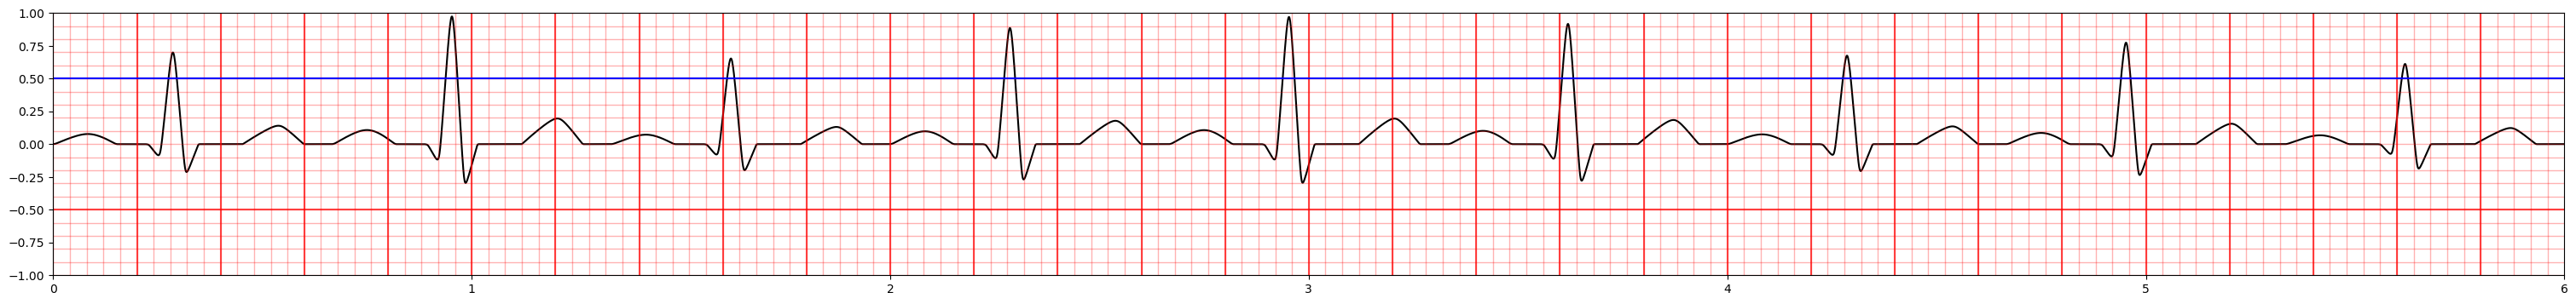

In [279]:
t = np.linspace(0,1,101)
patient_HR = 90
sensitivity = 0.5
x_ecg, y_ecg = stitch_beats(ECG_wave, patient_HR, regularity='Regular', sensitivity=sensitivity, rate=70, output=1.8, asynchronous=False)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_ecg, y_ecg, color='black')
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)

In [451]:
def third_deg_heart_block(ecg_func,iterations,sensitivity,output,rate,patient_HR,asynchronous=False):
    '''
    Function to simulate complete AV block with ventricular pacing
    
    Parameters:
    iterations: number of P and R waves to simulate
    sensitivity: sensitivity setting of pacemaker in mV
    output: output setting of pacemaker in mA
    rate: programmed rate of pacemaker in bpm
    patient_HR: intrinsic heart rate of patient in bpm
    asynchronous: boolean indicating if pacemaker is in asynchronous mode
    
    Returns:
    x: array of x coordinates of final ECG trace (includes pacing logic)
    y: array of y coordinates of final ECG trace (includes pacing logic)
    '''

    RR_interval = 60/patient_HR
    PP_interval = RR_interval*0.7

    storage = np.empty((3,iterations*2), dtype=object) #2D array to store P and R waves for each iteration of for loop. 1st row contains wave number, 2nd row contains x coordinates of trace, 3rd row contains y coordinates of trace
    max_vals = np.zeros([2,iterations*2]) #2D array to store max x value for each P and R wave for each iteration
    wave_num = 0 #Count to tell you which wave you're looking at 
    max_time_since_sensed = 60/rate  #Rate is rate set on pacemaker - not patient's intrinsic heartrate. When patient's ventricular rate falls below this value, paccemaker should pace
    capture_threshold = 1.5 + 0.4*np.random.random()-0.2 #Random capture threshold between 1.3mA and 1.7mA
    time_since_sensed = 0 #Counts how long it's been since an R wave was sensed. If this is longer than the max time since sensed, pacemaker should pace
    time_prev_sensed = 0
    beat_list = []

    x = np.array([]) #List to store final trace in x
    y = np.array([]) #List to store final trace in y
    
    


    while wave_num < iterations*2:  #wave number is increased by 2 at each iteration 
        #Calculate traces 
        Px, Py = ecg_func("3rd degree heart block P wave")
        Rx, Ry = ecg_func("3rd degree heart block R wave")
        paced_x, paced_y = ecg_func("3rd degree heart block ventricular pacing")
        
        #Scaling factors
        scaling_factor_x_R = 0.28/3.05 #Length of signal is 3.05, but actual length should be 0.28s
        scaling_factor_x_P = 0.06/0.9 #Length of signal is 0.9, but actual length should be 0.06s
        scaling_factor_x_paced = 0.4/3.872 #Length of signal is 3.872, but actual length should be 0.4s   
        scaling_factor_y_R = 0.295 + 0.06*np.random.random()-0.03
        scaling_factor_y_P = 0.1477 + 0.06*np.random.random()-0.03
        scaling_factor_y_paced = 1.333*(0.05 + 0.006*np.random.random()-0.003)

        #Apply scaling factors
        Px *= scaling_factor_x_P
        Py *= scaling_factor_y_P
        Rx *= scaling_factor_x_R
        Ry *= scaling_factor_y_R
        paced_x *= scaling_factor_x_paced
        paced_y *= scaling_factor_y_paced

        if wave_num == 0: #First beat
            PR_dist = 1 + 0.04*np.random.random()-0.02 #Random PR interval between 0.48 and 0.52 seconds

            Rx += PR_dist #Shift R wave by PR distance
            paced_x += max_time_since_sensed - 0.003305785 #Shift so pacing spike occurs at exactly max_time_since_sensed
            
            if asynchronous:
                if output >= capture_threshold: #If in asynchronous mode and capture threshold reached, should pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Px
                    storage[2,wave_num] = Py
                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Px)
                    wave_num += 1

                    storage[0,wave_num] = wave_num
                    storage[1, wave_num] = paced_x
                    storage[2,wave_num] = paced_y
                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(paced_x)
                    

                    wave_num += 1
                else: #If in asynchronous mode and capture threshold not reached, don't pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Px 
                    storage[2,wave_num] = Py
                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Px)

                    wave_num += 1

                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry
                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1

            elif np.max(np.abs(Ry)) > sensitivity: #Only sense in ventricles. Abs value used because independent of polarity
                idx = np.where(np.abs(Ry) >= sensitivity)[0][0] #First index where abs value of R wave higher than sensitivity threshold
                time_sensed = Rx[idx] 
                #Check if time since last sensed event exceeds max time allowed by pacemaker. If it does, need to put paced beat at max_time_since_sensed
                if time_sensed > max_time_since_sensed: #Time at which sensed too high --> should pace
                    if output >= capture_threshold: #If time at which sensed too high and output higher than capture threshold, should pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Px
                        storage[2,wave_num] = Py

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Px)

                        wave_num += 1

                        storage[0,wave_num] = wave_num
                        storage[1, wave_num] = paced_x
                        storage[2,wave_num] = paced_y

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(paced_x)

                        wave_num += 1

                        time_prev_sensed = np.min(paced_x) + 0.003305785
                        beat_list.append("Ventricular pacing")
                    else: #If time at which sensed too high, but capture threshold not reached, can't pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Px 
                        storage[2,wave_num] = Py

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Px)

                        wave_num += 1

                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Rx
                        storage[2,wave_num] = Ry

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Rx)

                        wave_num += 1

                        time_prev_sensed = time_sensed
                        beat_list.append("Normal")
                else: #If time at which sensed isn't too high, don't need to pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Px 
                    storage[2,wave_num] = Py

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Px)

                    wave_num += 1

                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1

                    time_prev_sensed = time_sensed
                    beat_list.append("Normal")
            else: #If sensitivity threshold isn't crossed
                time_since_sensed += np.max(Rx)
                if time_since_sensed > max_time_since_sensed:
                    if output >= capture_threshold: #If time since last sensed event too long and capture threshold reached, should pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Px
                        storage[2,wave_num] = Py

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Px)

                        wave_num += 1

                        storage[0,wave_num] = wave_num
                        storage[1, wave_num] = paced_x
                        storage[2,wave_num] = paced_y

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(paced_x)

                        wave_num += 1

                        time_prev_sensed = np.min(paced_x) + 0.003305785
                        time_since_sensed = 0
                        beat_list.append("Ventricular pacing")
                    else: #If time since last sensed event too high, but capture threshold not reached, can't pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Px 
                        storage[2,wave_num] = Py

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Px)

                        wave_num += 1

                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Rx
                        storage[2,wave_num] = Ry

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Rx)

                        wave_num += 1

                        beat_list.append("Normal")
                else: #If time since last sensed event not too high, don't need to pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Px 
                    storage[2,wave_num] = Py

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Px)

                    wave_num += 1

                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1

                    beat_list.append("Normal")



        else: #2nd beat onwards
            Px += PP_interval + np.min(storage[1,wave_num-2])
            
            
            if beat_list[(wave_num-1)//2-1]== 'Normal': #If previous R wave was normal
                Rx += np.min(storage[1,wave_num-2]) + RR_interval
            else: #If previous R wave was paced
                Rx += np.min(storage[1,wave_num-2]) + RR_interval + 0.003305785-0.050491803

            if asynchronous:
                if output >= capture_threshold: #If in asynchronous mode and capture threshold reached, should pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Px
                    storage[2,wave_num] = Py

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Px)

                    wave_num += 1

                    storage[0,wave_num] = wave_num
                    paced_x += max_time_since_sensed + np.min(storage[1,wave_num-2])-0.003305785 #Add max time since sensed to min of previous x trace of paced wave
                    storage[1, wave_num] = paced_x
                    storage[2,wave_num] = paced_y

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(paced_x)

                    wave_num += 1
                else: #If in asynchronous mode and capture threshold not reached, don't pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Px 
                    storage[2,wave_num] = Py

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Px)

                    wave_num += 1

                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1

            elif np.max(np.abs(Ry)) > sensitivity:
                idx = np.where(np.abs(Ry) >= sensitivity)[0][0] #First index where abs value of R wave higher than sensitivity threshold
                time_sensed = Rx[idx] 
                print(f'Wave number: {wave_num}, sensed at {time_sensed}')
                time_since_sensed = time_sensed-time_prev_sensed
                #Check if time since last sensed event exceeds max time allowed by pacemaker. If it does, need to put paced beat at max_time_since_sensed
                if time_since_sensed > max_time_since_sensed: #Time at which sensed too high --> should pace
                    if output >= capture_threshold: #If time at which sensed too high and output higher than capture threshold, should pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Px
                        storage[2,wave_num] = Py 

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Px)

                        wave_num += 1

                        storage[0,wave_num] = wave_num

                        if beat_list[(wave_num-1)//2-1]== 'Normal': #If previous R wave was normal
                            offset = max_time_since_sensed + time_prev_sensed - 0.003305785
                        else: #If previous R wave was paced
                            offset = np.min(storage[1,wave_num-2])+ max_time_since_sensed - 0.003305785

                        paced_x += offset
                        storage[1,wave_num] = paced_x
                        storage[2,wave_num] = paced_y
                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(paced_x)

                        wave_num += 1

                        time_prev_sensed = np.min(paced_x) + 0.003305785
                        beat_list.append("Ventricular pacing")
                        time_since_sensed = 0 
                    else: #If capture threshold not reached, can't pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Px
                        storage[2,wave_num] = Py
                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Px)

                        wave_num += 1

                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Rx
                        storage[2,wave_num] = Ry 
                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Rx)

                        wave_num += 1

                        time_prev_sensed = time_sensed
                        beat_list.append("Normal")
                        time_since_sensed = 0
                else: #If time since sensed isn't too high, don't pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Px
                    storage[2,wave_num] = Py

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Px)

                    wave_num += 1

                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry 

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1

                    time_prev_sensed = time_sensed
                    time_since_sensed = 0 
                    beat_list.append("Normal")
            else: #If sensitivity threshold isn't crossed
                time_since_sensed += np.max(Rx)

                if time_since_sensed > max_time_since_sensed: 
                    if output >= capture_threshold: #If time since sensed too long and capture threshold reached, need to pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Px 
                        storage[2,wave_num] = Py 

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Px)

                        wave_num += 1

                        storage[0,wave_num] = wave_num

                        if beat_list[(wave_num-1)//2-1] == 'Normal': #If previous beat was normal
                            offset = max_time_since_sensed + time_prev_sensed - 0.003305785
                        else:
                            offset = max_time_since_sensed + np.min(storage[1,wave_num-2]) - 0.003305785

                        paced_x += offset
                        storage[1,wave_num] = paced_x
                        storage[2,wave_num] = paced_y

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(paced_x)

                        wave_num += 1

                        time_prev_sensed = np.min(paced_x) + 0.003305785
                        beat_list.append("Ventricular pacing")
                        time_since_sensed = 0 
                    else: #If time since sensed too long, but capture threshold not reached, can't pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Px
                        storage[2,wave_num] = Py

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Px)

                        wave_num += 1

                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Rx
                        storage[2,wave_num] = Ry 

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Rx)
                        wave_num += 1
                        beat_list.append("Normal")
                else: #If time since sensed isn't too high, don't need to pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Px
                    storage[2,wave_num] = Py 

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Px)

                    wave_num += 1

                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)
                    wave_num += 1
                    beat_list.append("Normal")
                

            

    #Putting waves in order and preventing overlapping waves from plotting on top of e/o
    sort_idx = np.argsort(max_vals[1, :]) #Array of indexes that sort the max x value row 
    max_vals_sorted = max_vals[:, sort_idx] #Reorder both rows using these indexes. Array now contains traces in order  



    for i in range(wave_num):
        idx = max_vals_sorted[0,i] #Iterate through sorted array containing index of waves in order 
        idx = int(idx) #Convert index to integer 
        x_temp = storage[1,idx] #Take that specific x trace out of the storage array
        y_temp = storage[2,idx] #Take ordered y trace out of storage array 

        #Add wave for first index 
        if i == 0:
            x = np.concatenate((x,x_temp),axis=0)
            y = np.concatenate((y,y_temp),axis=0)
        
        #Check if overlap for subsequent waves 
        elif i > 0: 
            if np.min(x_temp) < np.max(x): #If there's overlap between R and P waves
                if np.max(y_temp) >= np.max(storage[2,idx-1]): #If new wave is R wave (max y value is bigger than max y value of previous wave), get rid of previous wave
                    cutoff = len(storage[1,idx-1]) #How much to cut off from array to get rid of P wave
                    x = x[:-cutoff] # get rid of old wave (P wave)
                    y = y[:-cutoff]
                    x = np.concatenate((x,x_temp),axis=0) #Add R wave
                    y = np.concatenate((y,y_temp),axis=0)
                #If new wave is P wave do nothing 
            else: #Otherwise, just add the new wave to the array 
                x = np.concatenate((x,x_temp),axis=0)
                y = np.concatenate((y,y_temp),axis=0)
    

    return x, y

In [460]:
def third_deg_heart_block(ecg_func,iterations,sensitivity,output,rate,patient_HR,asynchronous=False):
    '''
    Function to simulate complete AV block with ventricular pacing
    
    Parameters:
    iterations: number of P and R waves to simulate
    sensitivity: sensitivity setting of pacemaker in mV
    output: output setting of pacemaker in mA
    rate: programmed rate of pacemaker in bpm
    patient_HR: intrinsic heart rate of patient in bpm
    asynchronous: boolean indicating if pacemaker is in asynchronous mode
    
    Returns:
    x: array of x coordinates of final ECG trace (includes pacing logic)
    y: array of y coordinates of final ECG trace (includes pacing logic)
    '''

    RR_interval = 60/patient_HR
    PP_interval = RR_interval*0.7

    storage = np.empty((3,iterations*2), dtype=object) #2D array to store P and R waves for each iteration of for loop. 1st row contains wave number, 2nd row contains x coordinates of trace, 3rd row contains y coordinates of trace
    max_vals = np.zeros([2,iterations*2]) #2D array to store max x value for each P and R wave for each iteration
    wave_num = 0 #Count to tell you which wave you're looking at 
    max_time_since_sensed = 60/rate  #Rate is rate set on pacemaker - not patient's intrinsic heartrate. When patient's ventricular rate falls below this value, paccemaker should pace
    capture_threshold = 1.5 + 0.4*np.random.random()-0.2 #Random capture threshold between 1.3mA and 1.7mA
    time_since_sensed = 0 #Counts how long it's been since an R wave was sensed. If this is longer than the max time since sensed, pacemaker should pace
    time_prev_sensed = 0
    beat_list = []

    x = np.array([]) #List to store final trace in x
    y = np.array([]) #List to store final trace in y
    
    


    while wave_num < iterations*2:  #wave number is increased by 2 at each iteration 
        #Calculate traces 
        Px, Py = ecg_func("3rd degree heart block P wave")
        Rx, Ry = ecg_func("3rd degree heart block R wave")
        paced_x, paced_y = ecg_func("3rd degree heart block ventricular pacing")
        
        #Scaling factors
        scaling_factor_x_R = 0.28/3.05 #Length of signal is 3.05, but actual length should be 0.28s
        scaling_factor_x_P = 0.06/0.9 #Length of signal is 0.9, but actual length should be 0.06s
        scaling_factor_x_paced = 0.4/3.872 #Length of signal is 3.872, but actual length should be 0.4s   
        scaling_factor_y_R = 0.295 + 0.06*np.random.random()-0.03
        scaling_factor_y_P = 0.1477 + 0.06*np.random.random()-0.03
        scaling_factor_y_paced = 1.333*(0.05 + 0.006*np.random.random()-0.003)

        #Apply scaling factors
        Px *= scaling_factor_x_P
        Py *= scaling_factor_y_P
        Rx *= scaling_factor_x_R
        Ry *= scaling_factor_y_R
        paced_x *= scaling_factor_x_paced
        paced_y *= scaling_factor_y_paced

        if wave_num == 0: #First beat
            PR_dist = PP_interval/2 + 0.2*np.random.random()-0.1 #Initial random PR interval
            Rx += PR_dist #Shift R wave by PR distance
            
            storage[0,wave_num] = wave_num
            storage[1,wave_num] = Px
            storage[2,wave_num] = Py
            max_vals[0,wave_num] = wave_num
            max_vals[1,wave_num] = np.max(Px)
            offset_P = np.min(Px) + PP_interval
            wave_num += 1


            if asynchronous:
                if output >= capture_threshold: #If in asynchronous mode and capture threshold reached, should pace
                    paced_x += max_time_since_sensed - 0.003305785
                    storage[0,wave_num] = wave_num
                    storage[1, wave_num] = paced_x
                    storage[2,wave_num] = paced_y
                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(paced_x)
                
                    wave_num += 1
                    offset_async_capture = np.min(paced_x) + max_time_since_sensed
                else: #If in asynchronous mode and capture threshold not reached, don't pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry
                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1
                    offset_R = np.min(Rx) + RR_interval
            elif np.max(np.abs(Ry)) > sensitivity: #Only sense in ventricles. Abs value used because independent of polarity
                idx = np.where(np.abs(Ry) >= sensitivity)[0][0] #First index where abs value of R wave higher than sensitivity threshold
                time_sensed = Rx[idx] 
                #Check if time since last sensed event exceeds max time allowed by pacemaker. If it does, need to put paced beat at max_time_since_sensed
                if time_sensed > max_time_since_sensed: #Time at which sensed too high --> should pace
                    if output >= capture_threshold: #If time at which sensed too high and output higher than capture threshold, should pace
                        paced_x += max_time_since_sensed - 0.003305785 
                        storage[0,wave_num] = wave_num
                        storage[1, wave_num] = paced_x
                        storage[2,wave_num] = paced_y

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(paced_x)

                        wave_num += 1

                        offset_R = np.min(paced_x) + RR_interval
                        time_prev_sensed = np.min(paced_x) + 0.003305785
                        beat_list.append("Ventricular pacing")
                    else: #If time at which sensed too high, but capture threshold not reached, can't pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Rx
                        storage[2,wave_num] = Ry

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Rx)

                        wave_num += 1

                        offset_R = np.min(Rx) + RR_interval
                        time_prev_sensed = time_sensed
                        beat_list.append("Normal")
                else: #If time at which sensed isn't too high, don't need to pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1

                    offset_R = np.min(Rx) + RR_interval
                    time_prev_sensed = time_sensed
                    beat_list.append("Normal")
            else: #If sensitivity threshold isn't crossed
                time_since_sensed += np.max(Rx)
                if time_since_sensed > max_time_since_sensed:
                    if output >= capture_threshold: #If time since last sensed event too long and capture threshold reached, should pace
                        paced_x += max_time_since_sensed - 0.003305785
                        storage[0,wave_num] = wave_num
                        storage[1, wave_num] = paced_x
                        storage[2,wave_num] = paced_y

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(paced_x)

                        wave_num += 1

                        offset_R = np.min(paced_x) + RR_interval
                        time_prev_sensed = np.min(paced_x) + 0.003305785
                        time_since_sensed = 0
                        beat_list.append("Ventricular pacing")
                    else: #If time since last sensed event too high, but capture threshold not reached, can't pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Rx
                        storage[2,wave_num] = Ry

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Rx)

                        wave_num += 1

                        offset_R = np.min(Rx) + RR_interval
                        beat_list.append("Normal")
                else: #If time since last sensed event not too high, don't need to pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1

                    offset_R = np.min(Rx) + RR_interval
                    beat_list.append("Normal")



        else: #2nd beat onwards
            Px += offset_P
            Rx += offset_R

            #Add P wave to storage - do for all conditions
            storage[0,wave_num] = wave_num
            storage[1,wave_num] = Px
            storage[2,wave_num] = Py

            max_vals[0,wave_num] = wave_num
            max_vals[1,wave_num] = np.max(Px)

            offset_P = np.min(Px) + PP_interval

            wave_num += 1

            if asynchronous:
                if output >= capture_threshold: #If in asynchronous mode and capture threshold reached, should pace
                    paced_x += offset_async_capture
                    storage[0,wave_num] = wave_num
                    storage[1, wave_num] = paced_x
                    storage[2,wave_num] = paced_y

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(paced_x)

                    wave_num += 1
                    offset_async_capture = np.min(paced_x) + max_time_since_sensed
                else: #If in asynchronous mode and capture threshold not reached, don't pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    offset_R = np.min(Rx) + RR_interval
                    wave_num += 1

            elif np.max(np.abs(Ry)) > sensitivity:
                idx = np.where(np.abs(Ry) >= sensitivity)[0][0] #First index where abs value of R wave higher than sensitivity threshold
                time_sensed = Rx[idx] 
                time_since_sensed = time_sensed-time_prev_sensed
                #Check if time since last sensed event exceeds max time allowed by pacemaker. If it does, need to put paced beat at max_time_since_sensed
                if time_since_sensed > max_time_since_sensed: #Time at which sensed too high --> should pace
                    if output >= capture_threshold: #If time at which sensed too high and output higher than capture threshold, should pace

                        if beat_list[(wave_num-1)//2-1]== 'Normal': #If previous R wave was normal
                            offset_paced = max_time_since_sensed + time_prev_sensed - 0.003305785
                        else: #If previous R wave was paced
                            offset_paced = offset_R-RR_interval+max_time_since_sensed

                        paced_x += offset_paced
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = paced_x
                        storage[2,wave_num] = paced_y
                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(paced_x)

                        wave_num += 1

                        offset_R = np.min(paced_x)+RR_interval
                        time_prev_sensed = np.min(paced_x) + 0.003305785
                        beat_list.append("Ventricular pacing")
                        time_since_sensed = 0 
                    else: #If capture threshold not reached, can't pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Rx
                        storage[2,wave_num] = Ry 
                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Rx)

                        wave_num += 1

                        offset_R = np.min(Rx)+RR_interval
                        time_prev_sensed = time_sensed
                        beat_list.append("Normal")
                        time_since_sensed = 0
                else: #If time since sensed isn't too high, don't pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry 

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)

                    wave_num += 1

                    offset_R = np.min(Rx)+RR_interval
                    time_prev_sensed = time_sensed
                    time_since_sensed = 0 
                    beat_list.append("Normal")
            else: #If sensitivity threshold isn't crossed
                time_since_sensed += np.max(Rx)

                if time_since_sensed > max_time_since_sensed: 
                    if output >= capture_threshold: #If time since sensed too long and capture threshold reached, need to pace
                        
                        if beat_list[(wave_num-1)//2-1] == 'Normal': #If previous beat was normal
                            offset_paced = max_time_since_sensed + time_prev_sensed - 0.003305785
                        else:#If previous beat was paced
                            offset_paced = offset_R - RR_interval + max_time_since_sensed

                        paced_x += offset_paced
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = paced_x
                        storage[2,wave_num] = paced_y

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(paced_x)

                        wave_num += 1

                        offset_R = np.min(paced_x)+RR_interval
                        time_prev_sensed = np.min(paced_x) + 0.003305785
                        beat_list.append("Ventricular pacing")
                        time_since_sensed = 0 
                    else: #If time since sensed too long, but capture threshold not reached, can't pace
                        storage[0,wave_num] = wave_num
                        storage[1,wave_num] = Rx
                        storage[2,wave_num] = Ry 

                        max_vals[0,wave_num] = wave_num
                        max_vals[1,wave_num] = np.max(Rx)
                        wave_num += 1
                        offset_R = np.min(Rx)+RR_interval
                        beat_list.append("Normal")
                else: #If time since sensed isn't too high, don't need to pace
                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = Rx
                    storage[2,wave_num] = Ry

                    max_vals[0,wave_num] = wave_num
                    max_vals[1,wave_num] = np.max(Rx)
                    wave_num += 1
                    offset_R = np.min(Rx)+RR_interval
                    beat_list.append("Normal")
                

            

    #Putting waves in order and preventing overlapping waves from plotting on top of e/o
    sort_idx = np.argsort(max_vals[1, :]) #Array of indexes that sort the max x value row 
    max_vals_sorted = max_vals[:, sort_idx] #Reorder both rows using these indexes. Array now contains traces in order  



    for i in range(wave_num):
        idx = max_vals_sorted[0,i] #Iterate through sorted array containing index of waves in order 
        idx = int(idx) #Convert index to integer 
        x_temp = storage[1,idx] #Take that specific x trace out of the storage array
        y_temp = storage[2,idx] #Take ordered y trace out of storage array 

        #Add wave for first index 
        if i == 0:
            x = np.concatenate((x,x_temp),axis=0)
            y = np.concatenate((y,y_temp),axis=0)
        
        #Check if overlap for subsequent waves 
        elif i > 0: 
            if np.min(x_temp) < np.max(x): #If there's overlap between R and P waves
                if np.max(y_temp) >= np.max(storage[2,idx-1]): #If new wave is R wave (max y value is bigger than max y value of previous wave), get rid of previous wave
                    cutoff = len(storage[1,idx-1]) #How much to cut off from array to get rid of P wave
                    x = x[:-cutoff] # get rid of old wave (P wave)
                    y = y[:-cutoff]
                    x = np.concatenate((x,x_temp),axis=0) #Add R wave
                    y = np.concatenate((y,y_temp),axis=0)
                #If new wave is P wave do nothing 
            else: #Otherwise, just add the new wave to the array 
                x = np.concatenate((x,x_temp),axis=0)
                y = np.concatenate((y,y_temp),axis=0)
    

    return x, y

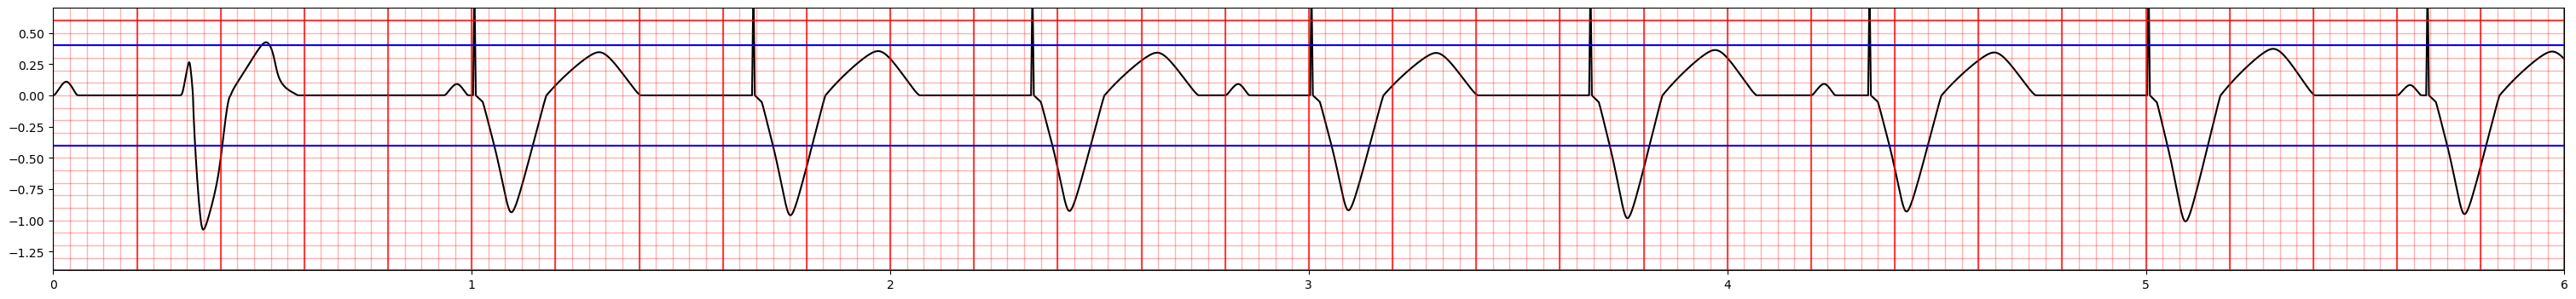

In [463]:
t = np.linspace(0,1,101)
iterations = 20
sensitivity = 0.4
output = 1.9
rate = 90
patient_HR = 90
x,y = third_deg_heart_block(ECG_wave, iterations,sensitivity,output,rate,patient_HR,asynchronous=False)

fig2, ax2 = plt.subplots(figsize=(38, 4))
ax2.plot(x,y, color='black')
ax2.set_xlim(0,8)

ax2.set_xlim(0, 6)
ax2.set_ylim(-1.4, 0.7)

# compute line positions 
big_lines_v = np.arange(0, 8, 0.2)
small_lines_v = np.arange(0, 8, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax2.get_ylim()
xmin, xmax = ax2.get_xlim()

# compute line positions 
big_lines_v = np.arange(0, 10, 0.2)
small_lines_v = np.arange(0, 10, 0.04)
big_lines_h = np.arange(-1.4, 0.7, 1)
small_lines_h = np.arange(-1.4, 0.7, 0.1)

# draw vertical lines (from ymin to ymax) in a single call each
ax2.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax2.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax2.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax2.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax2.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)
ax2.hlines(-sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)


# 3rd Degree AV Block #

In [ ]:
def complete_AV_block(ecg_func,iterations,sensitivity,output,rate,patient_HR,asynchronous=False):
    '''
    Function to simulate complete AV block with ventricular pacing
    
    Parameters:
    iterations: number of P and R waves to simulate
    sensitivity: sensitivity setting of pacemaker in mV
    output: output setting of pacemaker in mA
    rate: programmed rate of pacemaker in bpm
    patient_HR: intrinsic heart rate of patient in bpm
    asynchronous: boolean indicating if pacemaker is in asynchronous mode
    
    Returns:
    x: array of x coordinates of final ECG trace (includes pacing logic)
    y: array of y coordinates of final ECG trace (includes pacing logic)
    '''

    RR_interval = 60/patient_HR
    PP_interval = RR_interval-0.3 + 0.04*np.random.random()-0.02 #Random PP interval from 0.58s to 0.62s

    storage = np.empty((3,iterations*2), dtype=object) #2D array to store P and R waves for each iteration of for loop. 1st row contains wave number, 2nd row contains x coordinates of trace, 3rd row contains y coordinates of trace
    max_vals = np.zeros([2,iterations*2]) #2D array to store max x value for each P and R wave for each iteration
    wave_num = 0 #Count to tell you which wave you're looking at 
    max_time_since_sensed = 60/rate  #Rate is rate set on pacemaker - not patient's intrinsic heartrate. When patient's ventricular rate falls below this value, paccemaker should pace
    capture_threshold = 1.5 + 0.4*np.random.random()-0.2 #Random capture threshold between 1.3mA and 1.7mA
    time_since_sensed = 0 #Counts how long it's been since an R wave was sensed. If this is longer than the max time since sensed, pacemaker should pace


    x = [] #List to store final trace in x
    y = [] #List to store final trace in y

    while wave_num < iterations*2:  #wave number is increased by 2 at each iteration 
        #Need diff scaling factors for P and R waves 
        #scaling_factor_x = 0.8/9.51 #Need to apply scaling factor in x before calculating time since sensed. Duration of normal heart beat is 80ms - divide by 9.51 (length of heart beat in x axis)
        #scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(1.5795239721682306+3.996635592950172)

        #Scaling factors 
        # SF_x_R = 0.0393  
        # SF_x_R *= 2
        # SF_x_P = 0.0449
        # SF_x_P *= 3
        # SF_x_paced = 0.0413
        # SF_x_paced *= 2
        # SF_y_R = 0.295 + 0.06*np.random.random()-0.03
        # SF_y_P = 0.1477 + 0.06*np.random.random()-0.03
        # SF_y_paced = 0.05 + 0.006*np.random.random()-0.003
        # SF_y_paced *= 1.333

        scaling_factor_x_R = 0.28/3.05 #Length of signal is 3.05, but actual length should be 0.28s
        scaling_factor_x_P = 0.06/0.9 #Length of signal is 0.9, but actual length should be 0.06s
        scaling_factor_x_paced = 0.4/3.872 #Length of signal is 3.872, but actual length should be 0.4s   
        scaling_factor_y_R = 0.295 + 0.06*np.random.random()-0.03
        scaling_factor_y_P = 0.1477 + 0.06*np.random.random()-0.03
        scaling_factor_y_paced = 1.333*(0.05 + 0.006*np.random.random()-0.003)

        if wave_num == 0: #First beat
            PR_dist = 0.5 + 0.04*np.random.random()-0.02 #Random PR interval between 0.28 and 0.32 seconds

            #Calculate traces
            # start_x, start_y = b_polynomial(t, start)
            Px, Py = b_polynomial(t, points_P)
            R_firstx, R_firsty = b_polynomial(t, points_R_first)
            R_secondx, R_secondy = b_polynomial(t, points_R_second)
            R_thirdx, R_thirdy = b_polynomial(t, points_R_third)
            R_wavex = np.concatenate((R_firstx,R_secondx,R_thirdx),axis=0)
            R_wavey = np.concatenate((R_firsty,R_secondy,R_thirdy),axis=0)

            Px, Py = ecg_func("3rd degree heart block P wave")
            Rx, Ry = ecg_func("3rd degree heart block R wave")

            #Apply scaling factors
            Py *= SF_y_P 
            Px *= SF_x_P
            R_wavey *= SF_y_R
            R_wavex *= SF_x_R
            R_wavex += PR_dist #Shift R wave by PR distance
            # Px -= 0.2
            # R_wavex -= 0.2


            storage[0,wave_num]= wave_num #Enter the current wave number in the first row of first column of the storage array
            storage[1,wave_num] = Px #Enter the x trace of the first P wave in the second row of the first column of the storage array
            storage[2,wave_num] = Py #Enter the y trace of the first P wave in the third row of the first column of the storage array
            max_vals[0,wave_num]= wave_num #Enter the current wave number in the first row of first column of the max_vals array
            max_vals[1,wave_num] = np.max(Px) #Enter the max value of the x trace of the first P wave in the second row of the first column of the storage array
            wave_num += 1 #Increase the wave number by 1
            storage[0,wave_num]= wave_num
            storage[1,wave_num] = R_wavex
            storage[2,wave_num] = R_wavey
            max_vals[0,wave_num]= wave_num
            max_vals[1,wave_num] = np.max(R_wavex)
            wave_num += 1


            offset_P = np.max(Px) + PP_interval
            offset_R = np.max(R_wavex) + RR_interval


            #First wave should never be paced 

            #Increase time since last sensed event if beat is not sensed
            if np.max(R_wavey) < sensitivity: #Only sensing R wave, not P wave
                time_since_sensed += np.max(R_wavex) #Increase time since sensed event

        else: #2nd beat onwards
            Px, Py = b_polynomial(t, points_P)
            #Px += offset_P
            

            R_firstx, R_firsty = b_polynomial(t, points_R_first)
            #R_firstx += offset_R
            R_secondx, R_secondy = b_polynomial(t, points_R_second)
            #R_secondx += offset_R
            R_thirdx, R_thirdy = b_polynomial(t, points_R_third)
            #R_thirdx += offset_R

            R_wavex = np.concatenate((R_firstx,R_secondx,R_thirdx),axis=0)
            R_wavey = np.concatenate((R_firsty,R_secondy,R_thirdy),axis=0)
            R_wavey *= SF_y_R
            R_wavex *= SF_x_R
            R_wavex += offset_R
            Px *= SF_x_P
            Px += offset_P
            Py *= SF_y_P

            offset_P = np.max(Px) + PP_interval

            #P wave comes before R or paced beat and isn't used for sensing 
            storage[0,wave_num]= wave_num
            storage[1,wave_num] = Px
            storage[2,wave_num] = Py
            max_vals[0,wave_num]= wave_num
            max_vals[1,wave_num] = np.max(Px)
            wave_num += 1
            

            #Need to integrate pacing logic at this point in the code 
            if asynchronous: #If in asynchronous mode, pace regardless of sensing
                if output >= capture_threshold:
                    pacemaker_x, pacemaker_y = b_polynomial(t,points_Pacemaker)
                    pacedQRS_x,pacedQRS_y = b_polynomial(t,points_QRS)
                    T_x,T_y = b_polynomial(t,points_T)

                    paced_x = np.concatenate((pacemaker_x,pacedQRS_x,T_x),axis=0)
                    paced_y = np.concatenate((pacemaker_y,pacedQRS_y,T_y),axis=0)

                    #paced_x *= 0.7 #Where does 0.7 come from?
                    # paced_x += offset_R + 0.2*SF_x_paced #Shift so starts at same place as R wave would be (replace junctional escape rhythym which is unreliable with reliable ventricular paced rhythym)
                    # paced_y /= 5.5
                    paced_y *= SF_y_paced
                    paced_x *= SF_x_paced
                    paced_x += offset_R + 0.2*SF_x_paced #Shift so starts at same place as R wave would be (replace junctional escape rhythym which is unreliable with reliable ventricular paced rhythym)


                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = paced_x
                    storage[2,wave_num] = paced_y
                    max_vals[0,wave_num]= wave_num
                    max_vals[1,wave_num] = np.max(paced_x) 
                    #print(f"Wave number: {wave_num}, paced beat")
                    wave_num += 1
                    offset_R = np.min(paced_x) + (np.max(paced_x)-np.min(paced_x))/2 + RR_interval 
                else: #If output too low, get normal R wave instead of paced beat
                    storage[1,wave_num] = R_wavex
                    storage[2,wave_num] = R_wavey
                    max_vals[0,wave_num]= wave_num
                    max_vals[1,wave_num] = np.max(R_wavex)
                    wave_num += 1
                    offset_R = np.min(R_wavex) + (np.max(R_wavex)-np.min(R_wavex))/2 + RR_interval
                    time_since_sensed = 0 #Even though didn't pace, bc sensed, should reset time since sensed

            elif time_since_sensed >= max_time_since_sensed: 
                if output >= capture_threshold:
                    pacemaker_x, pacemaker_y = b_polynomial(t,points_Pacemaker)
                    pacedQRS_x,pacedQRS_y = b_polynomial(t,points_QRS)
                    T_x,T_y = b_polynomial(t,points_T)

                    paced_x = np.concatenate((pacemaker_x,pacedQRS_x,T_x),axis=0)
                    paced_y = np.concatenate((pacemaker_y,pacedQRS_y,T_y),axis=0)

                    #paced_x *= 0.7 #Where does 0.7 come from?
                    # paced_x += offset_R + 0.2*SF_x_paced #Shift so starts at same place as R wave would be (replace junctional escape rhythym which is unreliable with reliable ventricular paced rhythym)
                    # paced_y /= 5.5
                    paced_y *= SF_y_paced
                    paced_x *= SF_x_paced
                    paced_x += offset_R + 0.2*SF_x_paced #Shift so starts at same place as R wave would be (replace junctional escape rhythym which is unreliable with reliable ventricular paced rhythym)


                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = paced_x
                    storage[2,wave_num] = paced_y
                    max_vals[0,wave_num]= wave_num
                    max_vals[1,wave_num] = np.max(paced_x) 
                    #print(f"Wave number: {wave_num}, paced beat")
                    wave_num += 1
                    offset_R = np.min(paced_x) + (np.max(paced_x)-np.min(paced_x))/2 + RR_interval #Add offset to centre of wave
                    time_since_sensed = 0 #Reset time since sensed after pacing
                else: #If output too low, get normal R wave instead of paced beat
                    storage[1,wave_num] = R_wavex
                    storage[2,wave_num] = R_wavey
                    max_vals[0,wave_num]= wave_num
                    max_vals[1,wave_num] = np.max(R_wavex)
                    wave_num += 1
                    offset_R = np.min(R_wavex) + (np.max(R_wavex)-np.min(R_wavex))/2 + RR_interval
                    time_since_sensed = 0 #Even though didn't pace, bc sensed, should reset time since sensed

            else: #If rate from junctional escape beats is sufficient, don't pace
                storage[1,wave_num] = R_wavex
                storage[2,wave_num] = R_wavey
                max_vals[0,wave_num]= wave_num
                max_vals[1,wave_num] = np.max(R_wavex)
                #print(f"Wave number: {wave_num}, should be paced, but settings wrong")
                wave_num += 1
                offset_R = np.min(R_wavex) + (np.max(R_wavex)-np.min(R_wavex))/2 + RR_interval

                #Increase time since last sensed event if beat is not sensed
                if np.max(R_wavey) < sensitivity:
                    time_since_sensed += np.max(R_wavex) #Increase time since sensed event




    #Putting waves in order and preventing overlapping waves from plotting on top of e/o
    sort_idx = np.argsort(max_vals[1, :]) #Array of indexes that sort the max x value row 
    max_vals_sorted = max_vals[:, sort_idx] #Reorder both rows using these indexes. Array now contains traces in order  
    x = np.concatenate((x, start_x),axis = 0) #Start making the x array by adding the points in start_x
    y = np.concatenate((y, start_y),axis=0) #Start making the y array by adding the points in start_y

    for i in range(wave_num):
        idx = max_vals_sorted[0,i] #Iterate through sorted array containing index of waves in order 
        idx = int(idx) #Convert index to integer 
        x_temp = storage[1,idx] #Take that specific x trace out of the storage array
        y_temp = storage[2,idx] #Take ordered y trace out of storage array 

        # #Calculate the scaling factor in x
        # if i == 1: #Second wave in array is R wave - taking max x position of this gives length of 1 full cycle
        #     scaling_factor_x = 0.8/9.51

        #Add wave for first index 
        if i == 0:
            x = np.concatenate((x,x_temp),axis=0)
            y = np.concatenate((y,y_temp),axis=0)
        
        #Check if overlap for subsequent waves 
        elif i > 0: 
            if np.min(x_temp) < np.max(x): #If there's overlap between R and P waves
                if np.max(y_temp) >= np.max(storage[2,idx-1]): #If new wave is R wave (max y value is bigger than max y value of previous wave), get rid of previous wave
                    cutoff = len(storage[1,idx-1]) #How much to cut off from array to get rid of P wave
                    x = x[:-cutoff] # get rid of old wave (P wave)
                    y = y[:-cutoff]
                    x = np.concatenate((x,x_temp),axis=0) #Add R wave
                    y = np.concatenate((y,y_temp),axis=0)
                #If new wave is P wave do nothing 
            else: #Otherwise, just add the new wave to the array 
                x = np.concatenate((x,x_temp),axis=0)
                y = np.concatenate((y,y_temp),axis=0)
    
    #scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(1.5795239721682306+3.996635592950172)
    # x *= scaling_factor_x
    # y *= scaling_factor_y


    return x, y

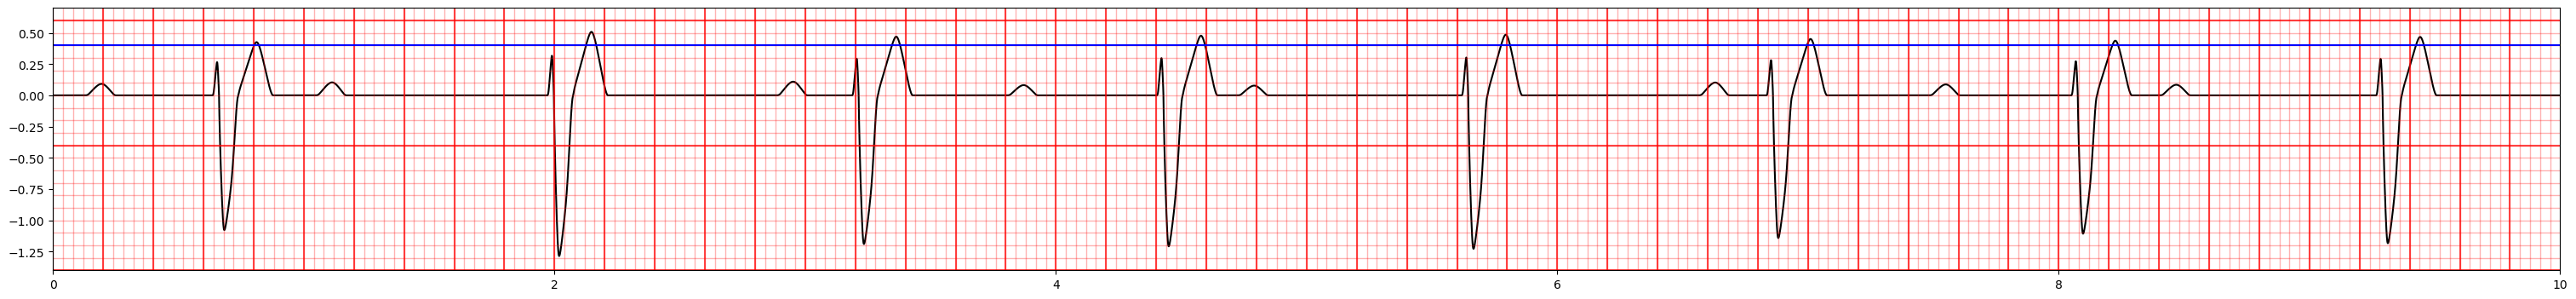

In [70]:
t = np.linspace(0,1,101)
iterations = 100
sensitivity = 0.4
output = 1.6
rate = 90
patient_HR = 80
x,y = complete_AV_block(iterations,sensitivity,output,rate,patient_HR,asynchronous=False)


fig2, ax2 = plt.subplots(figsize=(38, 4))
ax2.plot(x,y, color='black')
ax2.set_xlim(0,8)

ax2.set_xlim(0, 10)
ax2.set_ylim(-1.4, 0.7)

# compute line positions 
big_lines_v = np.arange(0, 8, 0.2)
small_lines_v = np.arange(0, 8, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax2.get_ylim()
xmin, xmax = ax2.get_xlim()

# compute line positions 
big_lines_v = np.arange(0, 10, 0.2)
small_lines_v = np.arange(0, 10, 0.04)
big_lines_h = np.arange(-1.4, 0.7, 1)
small_lines_h = np.arange(-1.4, 0.7, 0.1)

# draw vertical lines (from ymin to ymax) in a single call each
ax2.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax2.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax2.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax2.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax2.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)


# Mobitz Type II #


In [31]:
def Mobitz_type_II(ecg_func, gap, regularity, sensitivity,rate, output, asynchronous,iterations=100):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type 
    gap: base gap between beats
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker in mV
    rate: programmed rate of pacemaker in bpm 
    output: output setting of pacemaker in mA
    asynchronous: boolean indicating if pacemaker is in asynchronous mode

    Returns:
    x: concatenated x values of ECG waveform for 10 iterations
    y: concatenated y values of ECG waveform for 10 iterations
    '''
    #Need to add async option 
    #Maybe can add something so points in ECG wave function randomised 
    beat_list = ['Normal']
    offset = 0 
    time_since_sensed = 0 
    max_time_since_sensed = 60/rate 
    capture_threshold = 1.5 
    prob_conduction = 0.8
    if asynchronous:
        regularity = 'Regular' #Override regularity if asynchronous mode is on

    for i in range(iterations):
        rand_num = np.random.rand()
        #Will have to edit function so it checks sensitivity value at each iteration
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        #Only apply random scaling factor in x if regularity is 'Irregular', otherwise keep it constant
        
        if regularity == 'Irregular':
            scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
        else:
            scaling_factor_x = 0.8/(np.max(x_temp)-np.min(x_temp))
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))
        scaling_factor_y_heartblock = scaling_factor_y*0.08
        scaling_factor_x_heartblock = scaling_factor_x


        # print(f'Max in y is {np.max(y_temp)}, Min in y is {np.min(y_temp)}')
        # print(f'Max in x is {np.max(x_temp)}, Min in x is {np.min(x_temp)}')

        if offset == 0: #First beat in beat_list 
            R_location = 0
            #Apply scaling factors:
            if beat_list[i]=="Mobitz type II - no conduction":
                y_temp*= scaling_factor_y_heartblock
                x_temp*= scaling_factor_x_heartblock
            else:
                x_temp = x_temp*scaling_factor_x 
                y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Increase time since last sensed event if beat is not sensed
            if np.max(y_temp) < sensitivity:
                time_since_sensed += np.max(x_temp)
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    #THIS IS WRONG LOGIC - FIX
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        if rand_num <= prob_conduction: #80% chance of conduction 
                            beat_list.append("Normal") #If no capture, just append normal beat
                        else:
                            beat_list.append("Mobitz type II - no conduction")
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else: 
                    if rand_num <= prob_conduction:
                        beat_list.append('Normal')
                    else:
                        beat_list.append("Mobitz type II - no conduction")
    
            
            #If beat is sensed, then determine location of R wave
            else:
                #Determine R wave location
                R_location = x_temp[np.argmax(y_temp)]
                 #Append normal heart beat - need to determine distance between R waves of subsequent beats to choose whether to pace
                if asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else:
                    if rand_num <= prob_conduction:
                        beat_list.append('Normal')
                    else: 
                        beat_list.append("Mobitz type II - no conduction")
                time_since_sensed = 0

            #Apply offset for next beat
            offset = np.max(x_temp)

            
           

        else: #Second beat onwards
            #Apply scaling factors:
            if beat_list[i]=="Mobitz type II - no conduction":
                y_temp*= scaling_factor_y_heartblock
                x_temp*= scaling_factor_x_heartblock
            else:
                x_temp = x_temp*scaling_factor_x
                y_temp = y_temp*scaling_factor_y

            #Determine gap based on regularity of heart rhythm
            if regularity == 'Irregular':
                gap += np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap

            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)

            if np.max(y_temp) < sensitivity: #Increase time since last sensed event if beat is not sensed
                time_since_sensed += np.max(x_temp) + gap
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    else:
                        if rand_num <= prob_conduction:
                            beat_list.append("Normal") #If no capture, just append normal beat
                        else: 
                            beat_list.append("Mobitz type II - no conduction")
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: 
                    if rand_num <= prob_conduction:
                        beat_list.append('Normal')
                    else: 
                        beat_list.append("Mobitz type II - no conduction")

            else: #If beat is sensed, then determine location of R wave and calculate measured rate
                RR_dist = x_temp_shifted[np.argmax(y_temp)]-R_location
                #Convert distance between R waves to bpm
                measured_rate = 60/RR_dist
                
                #Update R_location for next iteration
                if beat_list[i] == "Ventricular pacing":
                    R_location = x_temp_shifted[np.argmin(y_temp)] #R wave is at minimum for paced beat
                else:
                    R_location = x_temp_shifted[np.argmax(y_temp)] #R wave is at maximum for normal beat
                    
                if measured_rate < rate: #If the measured rate is less than the programmed rate, append a paced beat and then a normal beat
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        if rand_num <= prob_conduction:
                            beat_list.append("Normal") #If no capture, just append normal beat
                        else: 
                            beat_list.append("Mobitz type II - no conduction")
                    if not asynchronous:
                        if prob_conduction <= 0.8:
                            beat_list.append("Normal") #I'm adding a normal beat after a paced beat, because I'm assuming the paced beat should have the correct heart rate
                        else: 
                            beat_list.append("Mobitz type II - no conduction")
                
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: #Otherwise append a normal beat
                    if rand_num <= prob_conduction:
                        beat_list.append('Normal')
                    else: 
                        beat_list.append("Mobitz type II - no conduction")


    return x, y


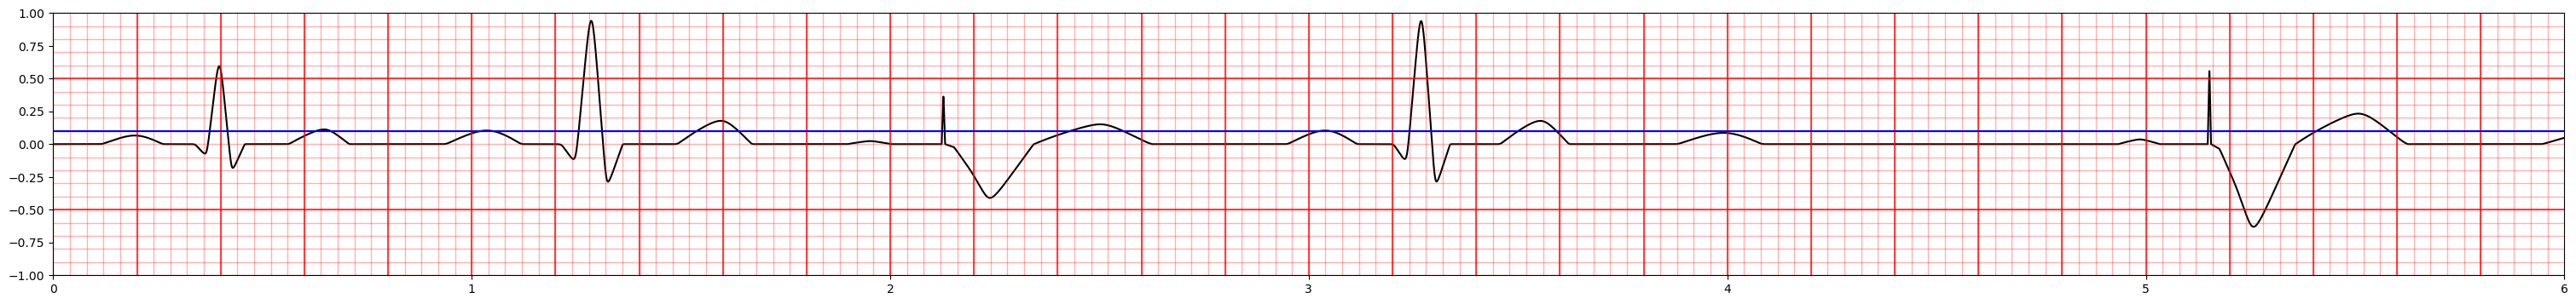

In [71]:
t = np.linspace(0,1,101)
patient_HR = 75
gap = heart_rate(patient_HR)
sensitivity = 0.1
x_ecg, y_ecg = Mobitz_type_II(ECG_wave, gap, regularity='Irregular', sensitivity=sensitivity, rate=70, output=1.5, asynchronous=False)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_ecg, y_ecg, color='black')
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)

# Slow Conduction #

In [ ]:
def slow_conduction(ecg_func, gap, regularity, sensitivity,rate, output, asynchronous,iterations=100):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type 
    gap: base gap between beats
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker in mV
    rate: programmed rate of pacemaker in bpm 
    output: output setting of pacemaker in mA
    asynchronous: boolean indicating if pacemaker is in asynchronous mode

    Returns:
    x: concatenated x values of ECG waveform for 10 iterations
    y: concatenated y values of ECG waveform for 10 iterations
    '''

    beat_list = ['Slow conduction']
    offset = 0 
    time_since_sensed = 0 
    max_time_since_sensed = 60/rate 
    capture_threshold = 1.5 
    if asynchronous:
        regularity = 'Regular' #Override regularity if asynchronous mode is on

    for i in range(iterations):
        #Will have to edit function so it checks sensitivity value at each iteration
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        #Only apply random scaling factor in x if regularity is 'Irregular', otherwise keep it constant
        if regularity == 'Irregular':
            #scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
            scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(24+2.582287981996621)
        else:
            scaling_factor_x = 0.8/(24+2.582287981996621)
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))

        if offset == 0: #First beat in beat_list 
            R_location = 0
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x 
            y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Increase time since last sensed event if beat is not sensed
            if np.max(y_temp) < sensitivity:
                time_since_sensed += np.max(x_temp)
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Slow conduction") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Slow conduction')
    
            
            #If beat is sensed, then determine location of R wave
            else:
                #Determine R wave location
                R_location = x_temp[np.argmax(y_temp)]
                 #Append normal heart beat - need to determine distance between R waves of subsequent beats to choose whether to pace
                if asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else:
                    beat_list.append('Slow conduction')
                time_since_sensed = 0

            #Apply offset for next beat
            offset = np.max(x_temp)

        else: #Second beat onwards
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x
            y_temp = y_temp*scaling_factor_y

            #Determine gap based on regularity of heart rhythm
            if regularity == 'Irregular':
                gap += np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap

            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)

            if np.max(y_temp) < sensitivity: #Increase time since last sensed event if beat is not sensed
                time_since_sensed += np.max(x_temp) + gap
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Slow conduction") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Slow conduction')

            else: #If beat is sensed, then determine location of R wave and calculate measured rate
                RR_dist = x_temp_shifted[np.argmax(y_temp)]-R_location
                #Convert distance between R waves to bpm
                measured_rate = 60/RR_dist
                
                #Update R_location for next iteration
                if beat_list[i] == "Ventricular pacing":
                    R_location = x_temp_shifted[np.argmin(y_temp)] #R wave is at minimum for paced beat
                else:
                    R_location = x_temp_shifted[np.argmax(y_temp)] #R wave is at maximum for normal beat
                    
                if measured_rate < rate: #If the measured rate is less than the programmed rate, append a paced beat and then a normal beat
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Slow conduction") #If no capture, just append normal beat
                    if not asynchronous:
                        beat_list.append("Slow conduction") #I'm adding a normal beat after a paced beat, because I'm assuming the paced beat should have the correct heart rate
                
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: #Otherwise append a normal beat
                    beat_list.append('Slow conduction')


    return x, y


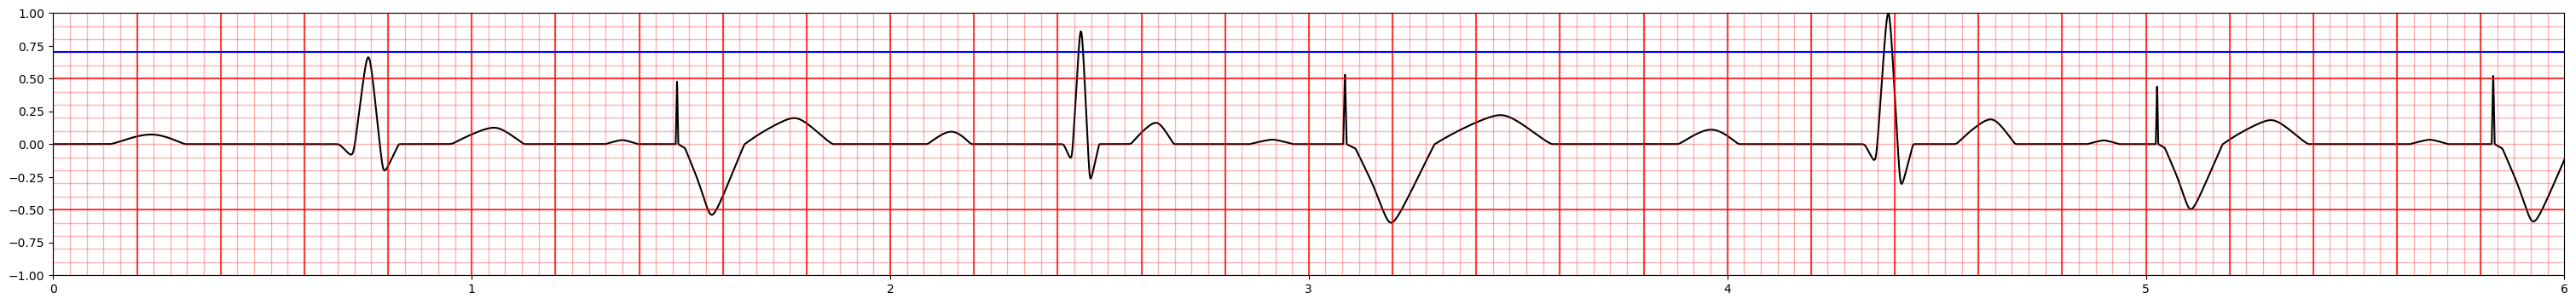

In [62]:
t = np.linspace(0,1,101)
patient_HR = 75
gap = heart_rate(patient_HR)
sensitivity = 0.7
x_ecg, y_ecg = slow_conduction(ECG_wave, gap, regularity='Irregular', sensitivity=sensitivity, rate=70, output=1.5, asynchronous=False)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_ecg, y_ecg, color='black')
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)